# Lab 2: Predictive Analytics with Machine Learning

**Duration:** 2 weeks [18 Jun - 25 Jun, 2026]
**Due Date:** 25th June, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

In this lab you will run a complete machine-learning workflow on **two real tabular datasets**,
covering both **supervised** and **unsupervised** learning:

| # | Task | Dataset | Type | Target |
|---|------|---------|------|--------|
| 1 | **Regression** | NYC Yellow Taxi trips | Supervised | `tip_amount` (continuous) |
| 2 | **Multi-class classification** | Obesity-level prediction | Supervised | `NObeyesdad` (7 classes) |
| 3 | **Clustering (K-Means)** | Obesity features (labels hidden) | Unsupervised | discover patient groups |

Along the way you will practise **NumPy, Pandas, and scikit-learn** to load and explore data,
clean and preprocess it, engineer features, split it into **train / validation / test** sets,
train models, **check for overfitting**, and discover hidden structure with clustering.

> **Note:** In this lab your *reasoning* is graded just as heavily as your *code*. Every section
> ends with a **Student Reasoning** box — fill it in with full sentences that justify your choices.

### Topics covered
Supervised learning (regression & classification), unsupervised learning (K-Means clustering),
feature engineering, train/validation/test splits, model evaluation, and overfitting.


---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-2-predictive-analytics` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_2_predictive_analytics.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas scikit-learn matplotlib seaborn`.
5. Commit and push your finished, fully-run notebook at the end.

**Local setup**
```bash
python -m venv .venv
source .venv/bin/activate        # Windows: .venv\Scripts\activate
pip install -r requirements.txt
jupyter lab
```

Open a new notebook, rename it, and run the cells below directly
(the datasets are loaded straight from their URLs, so no Drive mount is required).


In [15]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"



---
# Section 1 — Supervised Learning: Regression
## Predicting taxi `tip_amount` (NYC Yellow Taxi)

Each row is a completed taxi trip. Your goal is to **predict the tip a passenger leaves**
(`tip_amount`, a continuous value) from the trip's characteristics. The available columns are:

`VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID,
DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount`


### Part 1.1 — Load and explore the taxi data
Understand the shape, the data types, missing values, and the distribution of the target.

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


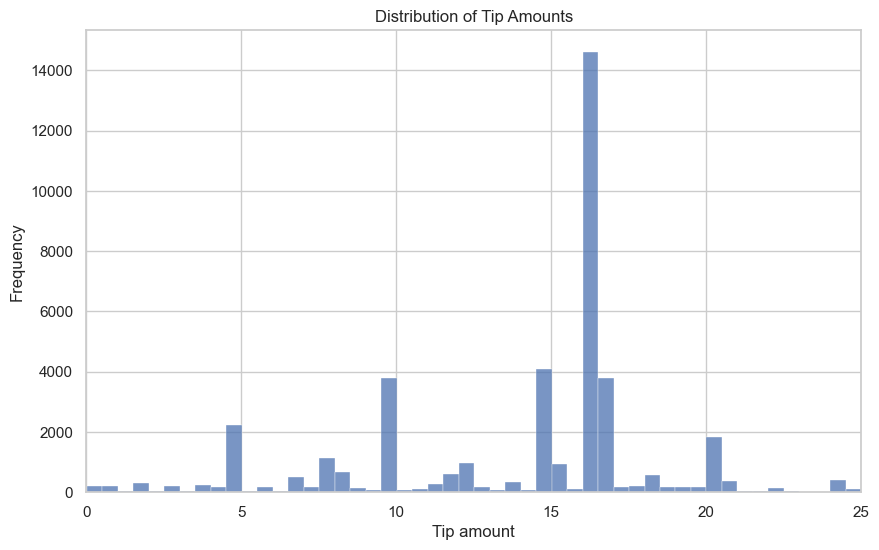

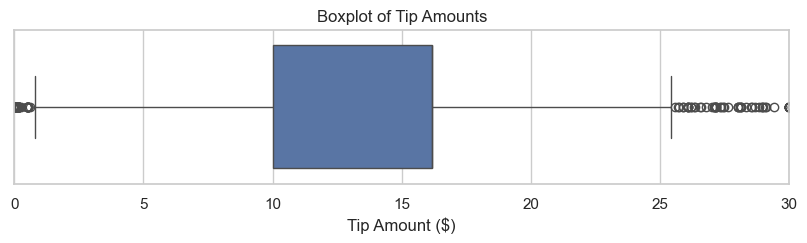

Number of invalid tip amounts (<=0):  0
Number of invalid fare amounts (<=0):  0
Number of tips greater than fare amounts:  24
mean amount for trips:  14.107666132712005
median amount for trips:  16.19
skewness of tip amounts:  1.2987388925352463
Number of outliers in tip_amount:  160


In [16]:
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
taxi.shape, 
taxi.head(), 
taxi.info() 
taxi.describe() 
taxi.isna().sum()


# TODO: Visualise the distribution of the target `tip_amount`
plt.figure(figsize =(10,6))
sns.histplot(data=taxi, x="tip_amount", binwidth=0.5, kde=False)
plt.xlim(0,25)
plt.xlabel('Tip amount')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amounts')  
plt.show()

#boxplot to view outliers. 
plt.figure(figsize=(10, 2))
sns.boxplot(x=taxi['tip_amount'])
plt.title('Boxplot of Tip Amounts')
plt.xlabel('Tip Amount ($)')
plt.xlim(0, 30)
plt.show()

# checking for invalid values 
print("Number of invalid tip amounts (<=0): ", (taxi['tip_amount']<=0).sum())
print("Number of invalid fare amounts (<=0): ", (taxi['fare_amount']<=0).sum())
print("Number of tips greater than fare amounts: ", (taxi['tip_amount']>taxi['fare_amount']).sum())

# tip statistics 
mean_trip = taxi['tip_amount'].mean()
median_trip = taxi['tip_amount'].median()
skew_trip = taxi['tip_amount'].skew()

print("mean amount for trips: ", mean_trip)
print("median amount for trips: ", median_trip)
print("skewness of tip amounts: ", skew_trip)

#using inter quartile range to determine outliers 
q1 = taxi['tip_amount'].quantile(0.25) 
q3 = taxi['tip_amount'].quantile(0.75) 
iqr = q3-q1 
upper = q3 + 1.5 * iqr 

#outliers here will be any tip greater than the upper limit.
outliers = (taxi['tip_amount']>upper).sum()


print("Number of outliers in tip_amount: ", (outliers))

**Student Reasoning — Taxi data exploration**
*What is the shape of the data? Are there missing values or impossible values
(e.g. negative tips, zero-distance trips)? What does the `tip_amount` distribution look like
(skew, outliers, many zeros)? How will this influence your preprocessing?*

> **Answer:** The data set has 41,202 rows and 13 columns and has no missing values. However there are invalid values, since 76 of the trips are less than 0. The distribution for trip_amount is right skewed as shown in the visualization and also from the skewness value of 1.30. the mean(average) tip is 14.11 and the most cocmon tip is 16.19. Tips typically range from 0.01 to 98.00 dollars. most trips fall between the 15 - 20 dollar range and there are about 777 outliers. For processing, we would remove the invalid trips and ignore outliers.  

### Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip.

In [17]:
# TODO: Handle missing / invalid rows
taxi_clean = taxi.copy() 

taxi_clean = taxi_clean[taxi_clean['trip_distance']>0]
taxi_clean = taxi_clean.drop(['PULocationID', 'DOLocationID'], axis=1)
# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#condensed the extra fees.
taxi_clean['total_extracharges']=(
  taxi_clean['mta_tax']+
  taxi_clean['tolls_amount']+
  taxi_clean['improvement_surcharge']
)

#fare per mile 
taxi_clean['fare_per_mile'] = taxi_clean['fare_amount'] / taxi_clean['trip_distance']


# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']

numeric_cols = ['passenger_count', 'trip_distance', 'fare_per_mile', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_extracharges', 'fare_per_mile', 'total_extra_charges']
taxi_encoded = pd.get_dummies(taxi_clean, columns=categorical_cols, drop_first=True)



**Student Reasoning — Taxi preprocessing**
*1. How did you handle missing/invalid rows and why?*
*2. Which new feature(s) did you engineer and what is the intuition behind them?*
*3. Which scaling method did you choose and why is it appropriate here?*

> **Answer:** There were no missing rows howeever there were invalid rows that were totally dropped. Here the trip_distance being less than 0 represent impossible trips and hence just have to dropped all together. Removed two columns because they are not essential for prediction. Fare_per_mile was created to capture trip cost efficiency and then the total extra charges to was captured because the extra charges may influence tipping. for the scaling method the one to be used would be the standard scaler on numeric features because it is more appropriate to use that for linear models and there are multiple outliers to be eliminated. 


### Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [18]:
# TODO: Separate features (X) and target (y = tip_amount)
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

x = taxi_encoded.drop('tip_amount', axis = 1)
y = taxi_encoded['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)  # 0.25 * 0.8 = 0.2

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
# Identify numeric columns for scaling
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 
                'tolls_amount', 'improvement_surcharge', 'fare_per_mile', 'total_extracharges']

# Fit scaler on TRAINING set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled = scaler.transform(X_val[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

# Replace original numeric columns with scaled versions
X_train_final = X_train.copy()
X_train_final[numeric_cols] = X_train_scaled

X_val_final = X_val.copy()
X_val_final[numeric_cols] = X_val_scaled

X_test_final = X_test.copy()
X_test_final[numeric_cols] = X_test_scaled

print(f"\nTraining features shape: {X_train_final.shape}")
print(f"Validation features shape: {X_val_final.shape}")
print(f"Test features shape: {X_test_final.shape}")

Train size: 24675
Validation size: 8225
Test size: 8226

Training features shape: (24675, 12)
Validation features shape: (8225, 12)
Test features shape: (8226, 12)


**Student Reasoning — Splitting**
*What ratio did you use? Why is a separate validation set useful in addition to a test set?
Why must the scaler (and any imputation statistics) be fit on the training data only?*

> **Answer:** A 60/20/20 split ratio was used. A separate validation set is useful because it's used to help tune parameters and select the best model without touching the actual test set which is used for the final evaluation. it is essentially like a preliminary test after the model has been trained before the final evaluation. The scalar is fit on only the training data because if it is fit on the full data set info from the validation and test set is gotten and then the model will learn that specific data and perform well wehn the tests are actually run giving false conviction that the model actually works properly. 


### Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on **train, validation, and test** sets.

Linear - Train: RMSE = $4.80, R² = 0.0512
Linear - Validation: RMSE = $5.04, R² = 0.0485
Linear - Test: RMSE = $5.01, R² = 0.0510
Random Forest - Train: RMSE = $4.14, R² = 0.2969
Random Forest - Validation: RMSE = $5.36, R² = -0.0768
Random Forest - Test: RMSE = $5.41, R² = -0.1058


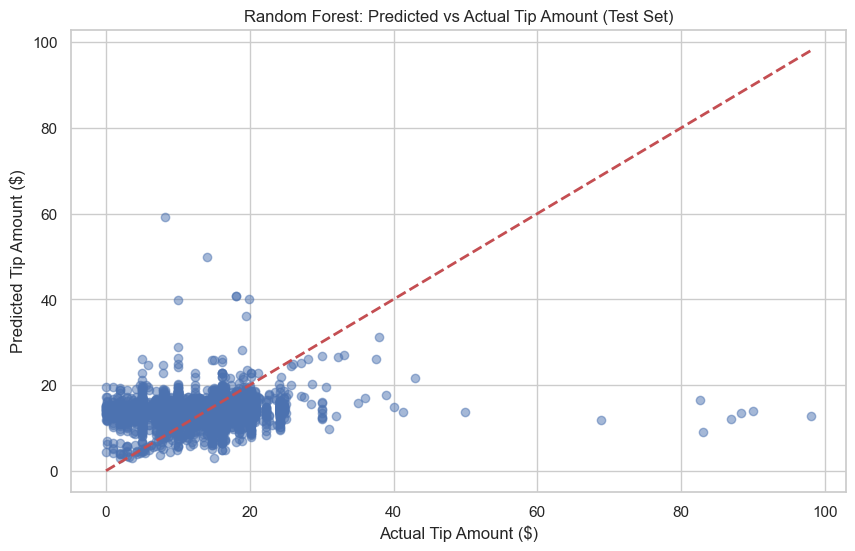

               feature  importance
1        trip_distance    0.334059
7        fare_per_mile    0.329596
2          fare_amount    0.151513
0      passenger_count    0.127120
6   total_extracharges    0.027387
4         tolls_amount    0.022878
10        RatecodeID_5    0.002227
3              mta_tax    0.002226
8         RatecodeID_2    0.001392
9         RatecodeID_4    0.001208


In [19]:
# TODO: Import, initialise, and train a regression model.
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score 
import numpy as np 

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_final, y_train) 

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_final, y_train)

# TODO: Predict on train, validation, and test sets.
y_train_pred_lr = lr.predict(X_train_final)
y_val_pred_lr = lr.predict(X_val_final)
y_test_pred_lr = lr.predict(X_test_final)

y_train_pred_rf = rf.predict(X_train_final)
y_val_pred_rf = rf.predict(X_val_final)
y_test_pred_rf = rf.predict(X_test_final)

# TODO: Report RMSE and R^2 for ALL THREE sets.
def evaluate_model(y_true, y_pred, model_name, dataset_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} - {dataset_name}: RMSE = ${rmse:.2f}, R² = {r2:.4f}")

evaluate_model(y_train, y_train_pred_lr, "Linear", "Train")
evaluate_model(y_val, y_val_pred_lr, "Linear", "Validation")
evaluate_model(y_test, y_test_pred_lr, "Linear", "Test")

evaluate_model(y_train, y_train_pred_rf, "Random Forest", "Train")
evaluate_model(y_val, y_val_pred_rf, "Random Forest", "Validation")
evaluate_model(y_test, y_test_pred_rf, "Random Forest", "Test")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_test_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Tip Amount ($)')
plt.ylabel('Predicted Tip Amount ($)')
plt.title('Random Forest: Predicted vs Actual Tip Amount (Test Set)')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10))

**Student Reasoning — Regression evaluation & overfitting**
*1. Which model performed best on the validation set, and which hyper-parameters did you try?*
*2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or
well-fitted? Quote the specific numbers that back up your claim.*
*3. What would you change to reduce overfitting if you saw it?*

> **Answer:** Random forest performed better on training datar with an R squared value of 0.2969 and Linear regression had 0.0512. Default hyper-parameters were used for the training data part. n_estimators = 100 and max_depth = default and min_samples_split = default. 

Comparing Training, Linear Regression:
 Train (RMSE = $4.80, R² = 0.0512), Val (RMSE = $5.04, R² = 0.0485), Test (RMSE = $5.01, R² = 0.0510)  Metrics are consistent across all sets with no overfitting, but R² values are very low, meaning features have little predictive power for tip amounts.

 Random Forest: 
 Train (RMSE = $4.14, R² = 0.2969), Val (RMSE = $5.36, R² = -0.0768), Test (RMSE = $5.41, R² = -0.1058) 
 Large gap between train and validation/test indicates severe overfitting. The model memorizes training data but fails to generalize. Negative R² on validation and test means it performs worse than predicting the mean.

 To reduce overfitting the max_depth can be reduced basically reducing the branches. 

---
# Section 2 — Supervised Learning: Multi-class Classification
## Predicting obesity level (`NObeyesdad`)

Each row describes a person's eating habits and physical condition. Predict their
**obesity category** `NObeyesdad`, which has **7 classes**: `Insufficient_Weight, Normal_Weight,
Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III`.

Feature columns: `Gender, Age, Height, Weight, family_history_with_overweight, FAVC, FCVC, NCP,
CAEC, SMOKE, CH2O, SCC, FAF, TUE, CALC, MTRANS`.


### Part 2.1 — Load and explore the obesity data
Look at the shape, dtypes, missing values, and especially the **class balance** of the target.

Shape: (2111, 17)
First five rows:
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight

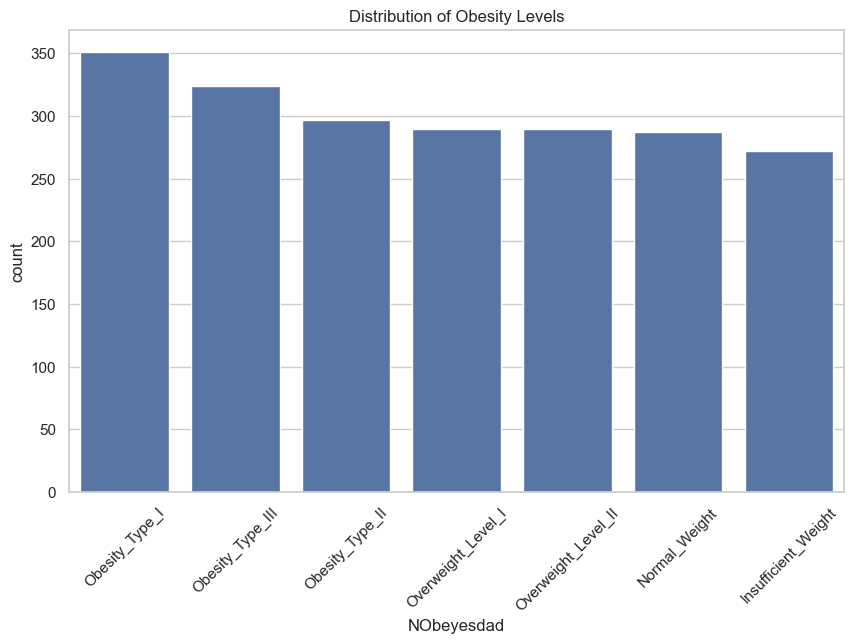

In [20]:
# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity = pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print("Shape:", obesity.shape)
print("First five rows:")
print(obesity.head())
print("info:", obesity.info())
print("describe:", obesity.describe())
print("Missing values:", obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
plt.figure(figsize=(10, 6))
sns.countplot(data=obesity, x='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title('Distribution of Obesity Levels')
plt.xticks(rotation=45)
plt.show()


**Student Reasoning — Obesity data exploration**
*How many rows/features are there? Which columns are categorical vs numeric? Is the target
balanced across the 7 classes, and why does class (im)balance matter for classification?*

> **Answer:** The dataset has 2,111 rows and 17 columns. The categorical columns are: (gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, MTRANS) and numeric (Age, Height, Weight, FCVC, NCP, CH20, FAF, TUE) variables. There are no missing values in any column. THe target NObeyesdad has 7 classes which are imbalanced. Class balance is more preferred because the model learns all classes of data evenly else it'll pick up a wrong pattern and may fail to work in other datasets. 

### Part 2.2 — Preprocessing & feature engineering
Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [21]:
# TODO: Encode categorical columns.
obesity_clean = obesity.copy() 

# Mapping the binary columns 
obesity_clean['family_history_with_overweight'] = obesity_clean['family_history_with_overweight'].map({'yes': 1, 'no': 0})
obesity_clean['FAVC'] = obesity_clean['FAVC'].map({'yes': 1, 'no': 0})
obesity_clean['SMOKE'] = obesity_clean['SMOKE'].map({'yes': 1, 'no': 0})
obesity_clean['SCC'] = obesity_clean['SCC'].map({'yes': 1, 'no': 0})

obesity_clean['CAEC_encoded'] = obesity_clean['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
obesity_clean['CALC_encoded'] = obesity_clean['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})

obesity_clean = pd.get_dummies(obesity_clean, columns=['Gender', 'MTRANS'], drop_first=True)

obesity_clean = obesity_clean.drop(['CAEC', 'CALC'], axis=1)

# Feature engineering 
obesity_clean['BMI'] = obesity_clean['Weight'] / (obesity_clean['Height'] ** 2)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
obesity_clean['NObeyesdad_encoded'] = le.fit_transform(obesity_clean['NObeyesdad'])

# Convert target to integer type (IMPORTANT FIX!)
obesity_clean['NObeyesdad_encoded'] = obesity_clean['NObeyesdad_encoded'].astype(int)

print("Class mapping:")
for i, label in enumerate(le.classes_):
    print(f"{i}: {label}")

numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

print(f"\nFeatures after preprocessing: {obesity_clean.shape[1]}")
print(f"Target column: NObeyesdad_encoded")
print(f"Target dtype: {obesity_clean['NObeyesdad_encoded'].dtype}")

Class mapping:
0: Insufficient_Weight
1: Normal_Weight
2: Obesity_Type_I
3: Obesity_Type_II
4: Obesity_Type_III
5: Overweight_Level_I
6: Overweight_Level_II

Features after preprocessing: 22
Target column: NObeyesdad_encoded
Target dtype: int64


**Student Reasoning — Obesity preprocessing**
*1. How did you encode each type of categorical variable, and why?*
*2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the
target is an obesity level.*
*3. Which scaler did you use and why?*

> **Answer:** [Double-click to edit]
Binary columns were converted to 0,1. and ordinary columns were converted to regular numbering 0,1,2,3. 
Gender, MTRANS have no order so no need to do ordinal encoding here its just converted to binary. with_drop = true is required because without dropping you'll have perfect correlation in some of the columns which makes it hard for the model to detect the patterns properly. 
BMI was created since it's a medical indicator for obesity, it is fair. the 7 obesity classes were converted to digits. Standard scaler to be used on numeric features .


### Part 2.3 — Stratified Train / Validation / Test split
With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [22]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity_clean.drop(['NObeyesdad', 'NObeyesdad_encoded'], axis=1)
y = obesity_clean['NObeyesdad_encoded']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# TODO: Fit the scaler on the training set only, then transform train / val / test.
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled = scaler.transform(X_val[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

X_train_final = X_train.copy()
X_train_final[numeric_cols] = X_train_scaled

X_val_final = X_val.copy()
X_val_final[numeric_cols] = X_val_scaled

X_test_final = X_test.copy()
X_test_final[numeric_cols] = X_test_scaled

print(f"\nTraining features shape: {X_train_final.shape}")
print(f"Validation features shape: {X_val_final.shape}")
print(f"Test features shape: {X_test_final.shape}")

Train size: 1266
Validation size: 422
Test size: 423

Training features shape: (1266, 20)
Validation features shape: (422, 20)
Test features shape: (423, 20)


**Student Reasoning — Splitting**
*What split ratio did you choose? Why is `stratify=y` important for this dataset?
What could go wrong if you split without stratifying?*

> **Answer:** [Double-click to edit] 60/20/20 was the split ratio used. stratify=y is necessary because the 7 obesity classes are imbalanced. Without stratify=y the split is random and can place all instances of a rare class in a test. the model then never learns to identify that class. WIth stratify=y we ensure that the data is properly proportioned across test, and training sets. Stratify=y is just a way of saying the proportion of each class in y is the same in both the training set and the original data. 

In [23]:
print(type(y_train))
print(y_train.dtype)
print(y_train.unique()[:10])
print(y_train.name)

<class 'pandas.Series'>
int64
[0 6 2 3 5 4 1]
NObeyesdad_encoded


### Part 2.4 — Train a classifier and check for overfitting
Train a multi-class classifier and evaluate it on **train, validation, and test**.

Logistic Regression:
LR - Train: Accuracy = 0.9281, Macro-F1 = 0.9258
LR - Validation: Accuracy = 0.8839, Macro-F1 = 0.8779
LR - Test: Accuracy = 0.9007, Macro-F1 = 0.8972

Random Forest:
RF - Train: Accuracy = 1.0000, Macro-F1 = 1.0000
RF - Validation: Accuracy = 0.9929, Macro-F1 = 0.9925
RF - Test: Accuracy = 0.9976, Macro-F1 = 0.9974


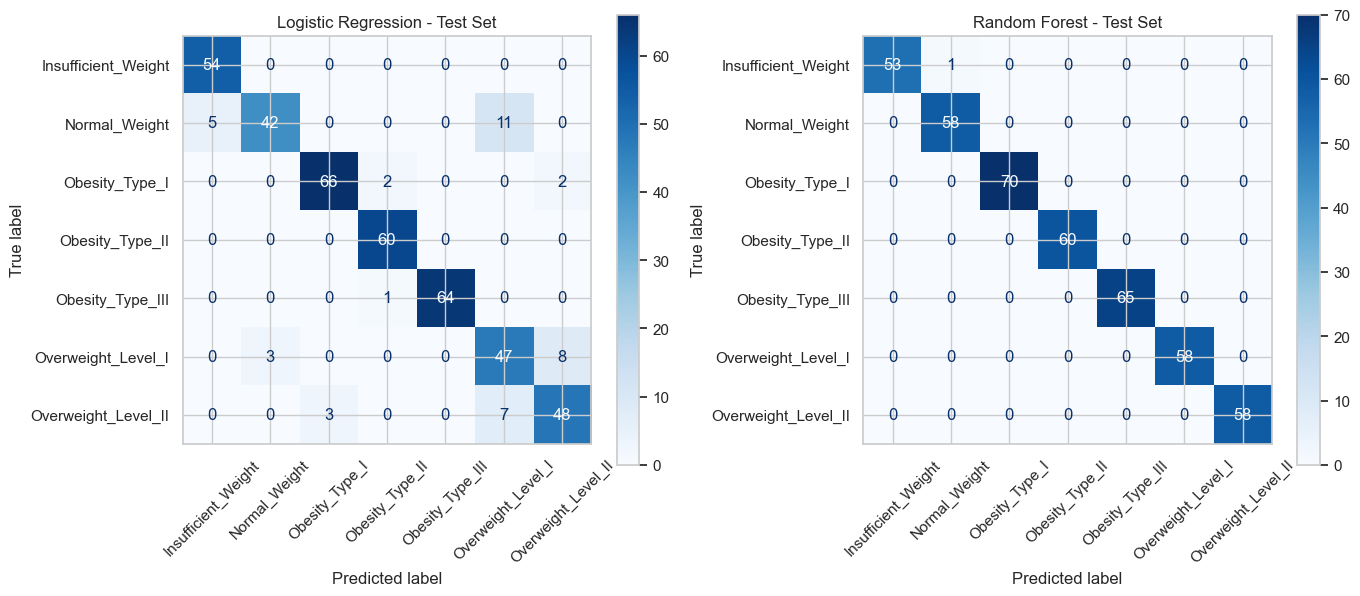


Classification Report - Random Forest (Test Set):
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.98      1.00      0.99        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       423
          macro avg       1.00      1.00      1.00       423
       weighted avg       1.00      1.00      1.00       423



In [24]:
# TODO: Import, initialise, and train a classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Model 1: Logistic Regression (removed multi_class parameter)
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf.fit(X_train_final, y_train)

# Model 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train_final, y_train)

# TODO: Predict on train, validation, and test.
y_train_pred_lr = lr_clf.predict(X_train_final)
y_val_pred_lr = lr_clf.predict(X_val_final)
y_test_pred_lr = lr_clf.predict(X_test_final)

y_train_pred_rf = rf_clf.predict(X_train_final)
y_val_pred_rf = rf_clf.predict(X_val_final)
y_test_pred_rf = rf_clf.predict(X_test_final)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
def evaluate_classifier(y_true, y_pred, model_name, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{model_name} - {dataset_name}: Accuracy = {acc:.4f}, Macro-F1 = {f1:.4f}")

print("Logistic Regression:")
evaluate_classifier(y_train, y_train_pred_lr, "LR", "Train")
evaluate_classifier(y_val, y_val_pred_lr, "LR", "Validation")
evaluate_classifier(y_test, y_test_pred_lr, "LR", "Test")

print("\nRandom Forest:")
evaluate_classifier(y_train, y_train_pred_rf, "RF", "Train")
evaluate_classifier(y_val, y_val_pred_rf, "RF", "Validation")
evaluate_classifier(y_test, y_test_pred_rf, "RF", "Test")

# TODO: Show a confusion matrix for the test set
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_estimator(lr_clf, X_test_final, y_test, 
                                       display_labels=le.classes_, 
                                       ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression - Test Set')
axes[0].set_xticklabels(le.classes_, rotation=45)

# Random Forest confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_clf, X_test_final, y_test, 
                                       display_labels=le.classes_, 
                                       ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest - Test Set')
axes[1].set_xticklabels(le.classes_, rotation=45)

plt.tight_layout()
plt.show()

# Classification report for best model
print("\nClassification Report - Random Forest (Test Set):")
print(classification_report(y_test, y_test_pred_rf, target_names=le.classes_))

**Student Reasoning — Classification evaluation & overfitting**
*1. Which classifier did you choose and why?*
*2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting,
or well-fitted? Cite the specific metrics.*
*3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might
that be?*

> **Answer:** Random forest because it is able to capture non-linear interactions between features that a linear model can't.

for Logistic Regression(Train=0.928, Val = 0.878 and Test = 0.901). The test is slightly larger than train so overfitting is minimal.

Random forest has(t =100, val=99.3, and test =99.8). These values would typically suggest that the model is a very effective one. However because of their near perfection it suggests also that there's a category making the task too easy and here it can be attributed to our BMI feature which is highly correlated already with obesity. 

For better results, the Random forest should work without the bmi feature. That way we see if the model is able to actually tell patterns. 



---
# Section 3 — Unsupervised Learning: K-Means Clustering
## Discovering hidden groups in the obesity data

Now **pretend you never had the `NObeyesdad` labels.** Using only the *scaled feature matrix*
from Section 2, use **K-Means** to see whether people naturally fall into distinct profiles —
and then compare those clusters to the real obesity levels.


### Part 3.1 — Choose k, fit K-Means, and visualise


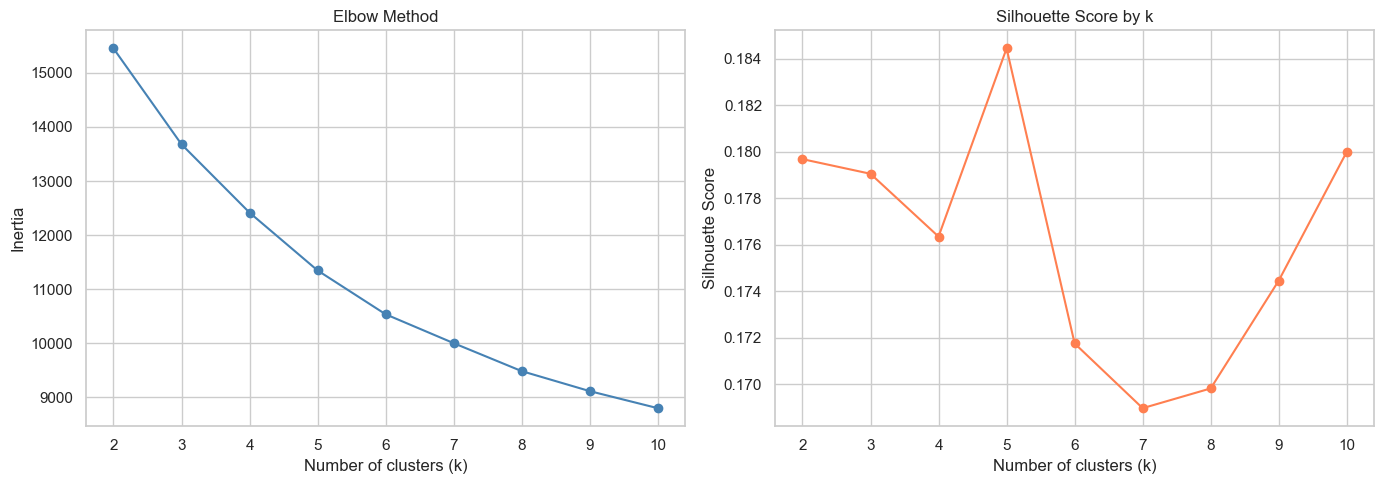

k=2: inertia=15452.9, silhouette=0.180
k=3: inertia=13679.1, silhouette=0.179
k=4: inertia=12416.0, silhouette=0.176
k=5: inertia=11346.8, silhouette=0.184
k=6: inertia=10536.4, silhouette=0.172
k=7: inertia=10002.5, silhouette=0.169
k=8: inertia=9485.1, silhouette=0.170
k=9: inertia=9115.3, silhouette=0.174
k=10: inertia=8799.9, silhouette=0.180
Cluster sizes:
0    259
1    403
2    270
3    208
4    348
5    386
6    237
Name: count, dtype: int64


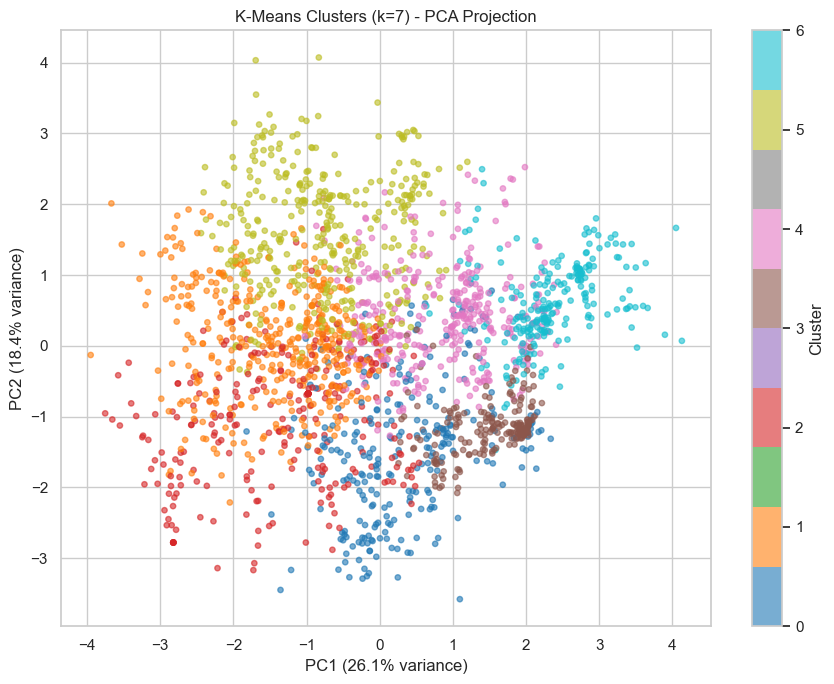

Total variance explained by 2 PCs: 44.5%


In [25]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']
scaler_full = StandardScaler()
X_obesity_scaled = scaler_full.fit_transform(obesity_clean[numeric_cols])

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_obesity_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_obesity_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, marker='o', color='coral')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.3f}")

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
best_k = 7

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_obesity_scaled)

print(f"Cluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index()}")

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_obesity_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', alpha=0.6, s=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'K-Means Clusters (k={best_k}) - PCA Projection')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [26]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?
comparison = pd.crosstab(cluster_labels, obesity_clean['NObeyesdad'], rownames=['Cluster'], colnames=['True Label'])
print(comparison)

True Label  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Cluster                                                          
0                             2             11              82   
1                            90            126              44   
2                            51             50              54   
3                             0              0               1   
4                             0              9             114   
5                           129             91              37   
6                             0              0              19   

True Label  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Cluster                                                             
0                        52                 0                  45   
1                         0                 0                  80   
2                        18                 0                  66   
3                        17               187               

**Student Reasoning — Clustering**
*1. How did you choose k? Quote the Elbow/silhouette evidence.*
*2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
Where do they agree and where do they break down?*
*3. In a real public-health setting where labels are expensive to collect, what would these
clusters be useful for?*

> **Answer:** [Double-click to edit] k = 7 was chosen to match the number of true categories. This is not from the elbow method. inertia declined smoothly from k=2 to k=10 with no sharp bend, and silhouette scores stayed in a narrow, flat range(0.169=0.184) across all k, with the highest score actually occuring at k =5 rather than k=7. This flatness suggests that the obesity dataset doesn't contain strong separate clusters.


Partially. Comparing the 7 clusters against the real labels we see that cluster 3 187/207 people were also in the Obesity_type_III category hinting on a good aggreement. Cluster 6 had most of its combination in Obesity_Type_III and II. Cluster had majority in type 1 and 2. however for the rest of the clusters they were spread with no clear dominating category.

If labels are expensive K means is still releavnt here. Because even tho it could not split it perfectly into the categories it was able to at least get us a split were it was severe. We could clearly tell which were the most obese and who were in the normal_weight range as well. In a public health setting it allows medics to at least know who need critical attention.

---
# Section 4 — Reflection

*Answer in a few sentences each:*

1. **Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and
   vice-versa?
The classifiers had access to labels during training so were able to do appropriate mappings which K means could not do that because it had no labels. It does not no about categories and hence created patterns on its own by observing trends. With K means it was hard to get dominant categories in certain clasters because with the BMI scale we did not have big numerical gaps.

2. **Regression vs classification:** How did evaluating a continuous target (tips) differ from
   evaluating a categorical one (obesity level)?

With using regression models we needed to use a continuous metric that would show us how far off we are from the true value. With the obsesity classifier we had to use accuracy and macro-f1. Because it was more binary it's either it matched or didn't. Macro-f1 here was used because it was an imbalance in the 7 classes. 


3. **Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and
   what is the single most effective thing you did (or would do) to close it?

> **Answer:**
Thee most severe overfitting appeared in the taxi regression model specifcally the Random forest because R^2 dropped from 0.297 to -0.077 and then -0.106. This drop suggest it performed considerably worse on the test and validation datasets. To fix this, some branches would need to be removed, we can do this by reducing the max_depth this way trees can learn broader. 


---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel → Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook.
- [ ] Notebook committed and pushed to your `lab-2-predictive-analytics` repository.
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository

---
#### Grading guide (100 pts)
| Area | Pts |
|------|-----|
| Section 1 — Regression (load, preprocess, split, model, overfitting) | 30 |
| Section 2 — Classification (load, preprocess, stratified split, model, overfitting) | 30 |
| Section 3 — K-Means clustering (k selection, fit, visualise, compare) | 20 |
| Reasoning boxes & Section 4 reflection | 15 |
| Reproducibility (runs clean, random_state, tidy code) | 5 |
